# Learning HMM parameters from data: continuous (Gaussian) emissions

The [previous post](hmm-learning-discrete.html) learned a *discrete* HMM -- the observation was a category (`walk`/`shop`/`clean`). But most signals we actually measure are **real numbers**: temperature, acceleration, and -- the case we are building toward -- the **power** drawn by an appliance.

So we swap the categorical emission for a **Gaussian** one: each hidden state has a mean level $\mu_k$ and a noise spread $\sigma_k$, and the observation is $y_t \sim \mathcal{N}(\mu_{z_t}, \sigma_{z_t})$. This is the entire change to the model -- everything else (priors, enumeration, SVI) is exactly as before. Varying the emission is varying the graphical model, and the inference machinery just follows along.

As before: fix true parameters, generate data, learn them back, check.

In [1]:
import torch
import pyro
import pyro.distributions as dist
from pyro.ops.indexing import Vindex
from pyro.infer import SVI, TraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.infer.autoguide import AutoDelta, init_to_sample
from pyro import poutine

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pyro.set_rng_seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

/Users/nipun/git/hmm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## A Gaussian-emission HMM

Think of a signal that hops between a few **levels** and stays in each for a while -- a device idling, running, and boosting, say. We use three states with distinct mean levels and small noise. These are the true parameters we will hide from the learner.

In [2]:
states = ["low", "mid", "high"]
K = 3

pi_true = torch.tensor([0.5, 0.3, 0.2])
A_true  = torch.tensor([[0.80, 0.15, 0.05],
                        [0.10, 0.80, 0.10],
                        [0.05, 0.15, 0.80]])
mu_true = torch.tensor([0.0, 5.0, 10.0])     # mean level per state
sd_true = torch.tensor([0.7, 0.7, 0.7])      # noise per state

def generate(num_seqs, T, seed=1):
    g = torch.Generator().manual_seed(seed)
    obs = torch.zeros(num_seqs, T)
    Z   = torch.zeros(num_seqs, T, dtype=torch.long)
    for s in range(num_seqs):
        z = torch.multinomial(pi_true, 1, generator=g).item()
        for t in range(T):
            if t > 0:
                z = torch.multinomial(A_true[z], 1, generator=g).item()
            Z[s, t] = z
            obs[s, t] = mu_true[z] + sd_true[z] * torch.randn(1, generator=g).item()
    return obs, Z

obs, Z = generate(num_seqs=30, T=120, seed=1)
print("data:", tuple(obs.shape))

data: (30, 120)


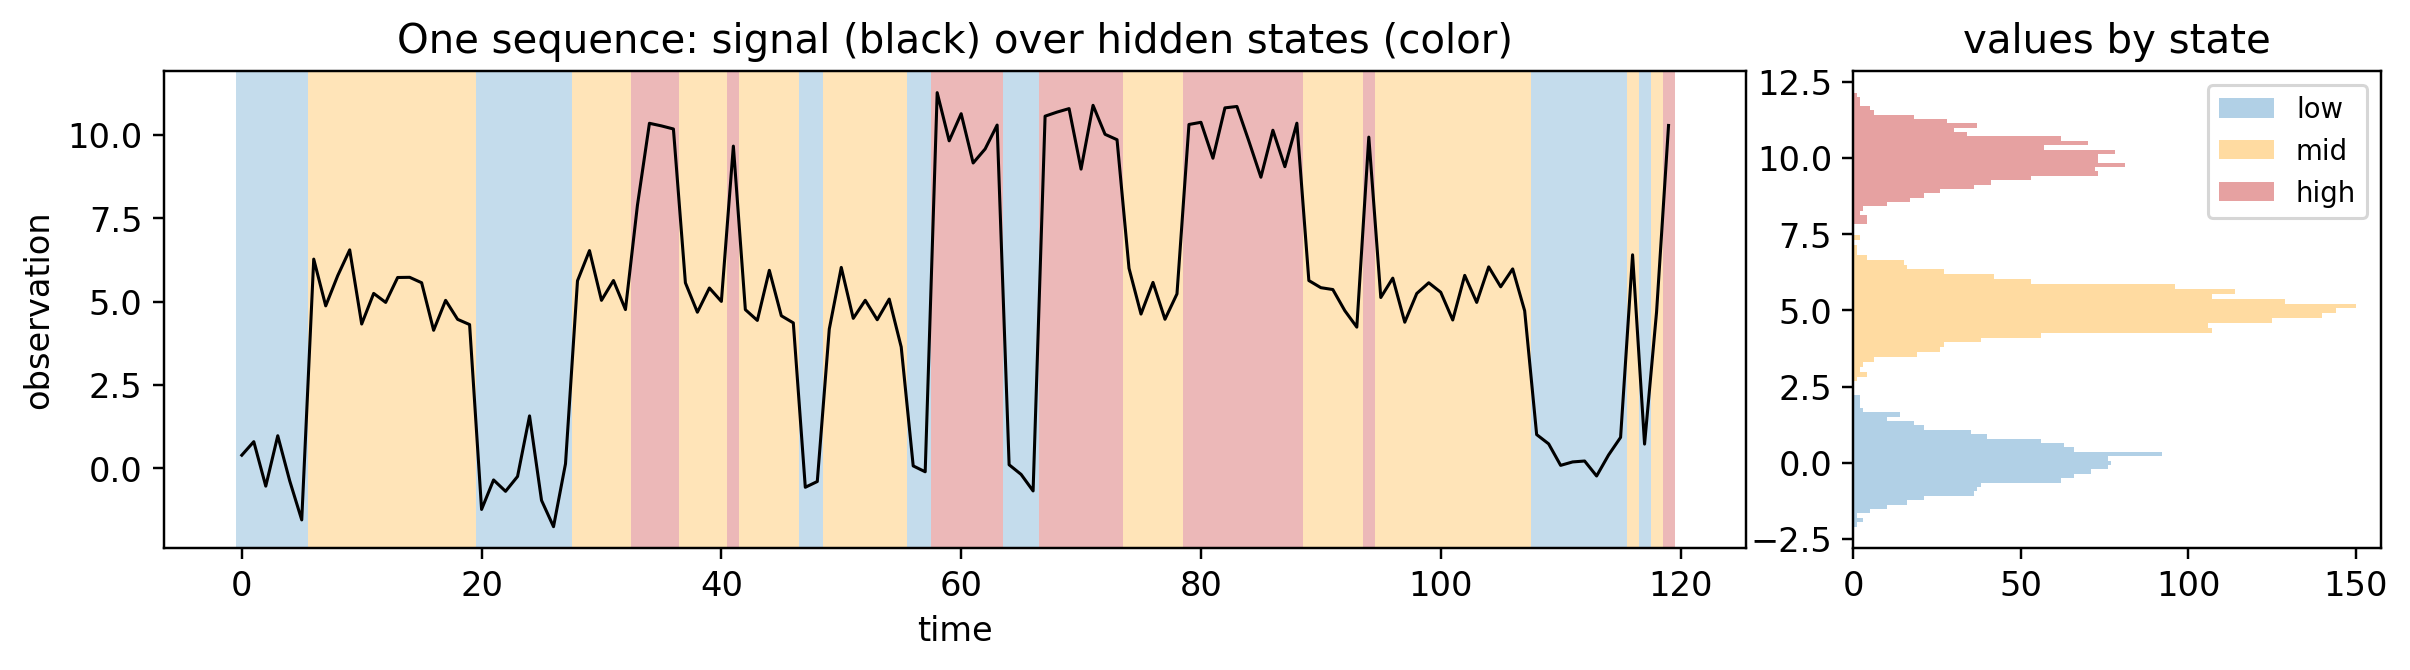

In [3]:
colors = ["#9ec5e0", "#ffd28a", "#e08a8a"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [3, 1]})
seq = obs[0].numpy(); zs = Z[0].numpy(); T = len(seq)
for t in range(T):
    a1.axvspan(t-0.5, t+0.5, color=colors[zs[t]], alpha=0.6, lw=0)
a1.plot(seq, color="k", lw=1)
a1.set_title("One sequence: signal (black) over hidden states (color)")
a1.set_xlabel("time"); a1.set_ylabel("observation")
for k in range(K):
    a2.hist(obs[Z == k].numpy(), bins=30, color=colors[k], alpha=0.8, label=states[k], orientation="horizontal")
a2.set_title("values by state"); a2.legend(fontsize=9)
plt.tight_layout(); plt.show()

## The learnable model

Same skeleton as the discrete post. The hidden chain is unchanged; only the emission line differs -- `Normal` instead of `Categorical`, with two sets of unknowns:

- `locs` (the means $\mu_k$), given a broad `Normal` prior centred on the data;
- `scales` (the spreads $\sigma_k$), given a positive `LogNormal` prior.

States are enumerated (summed out), parameters are point-estimated with `AutoDelta`, and we keep the best of a few random restarts since Gaussian EM is prone to local optima (e.g. two states grabbing one cluster).

In [4]:
def model(obs, K):
    S, T = obs.shape
    probs_init  = pyro.sample("probs_init",  dist.Dirichlet(torch.ones(K)))
    probs_trans = pyro.sample("probs_trans", dist.Dirichlet(torch.ones(K, K)).to_event(1))
    locs   = pyro.sample("locs",   dist.Normal(obs.mean(), 3 * obs.std()).expand([K]).to_event(1))
    scales = pyro.sample("scales", dist.LogNormal(0.0, 1.0).expand([K]).to_event(1))
    with pyro.plate("seqs", S, dim=-1):
        z = None
        for t in pyro.markov(range(T)):
            probs = probs_init if t == 0 else Vindex(probs_trans)[..., z, :]
            z = pyro.sample(f"z_{t}", dist.Categorical(probs), infer={"enumerate": "parallel"})
            pyro.sample(f"y_{t}", dist.Normal(Vindex(locs)[..., z], Vindex(scales)[..., z]),
                        obs=obs[:, t])

def learn(obs, K, steps=300, lr=0.05, seed=0):
    pyro.clear_param_store(); pyro.set_rng_seed(seed)
    guide = AutoDelta(poutine.block(model, expose=["probs_init", "probs_trans", "locs", "scales"]),
                      init_loc_fn=init_to_sample)
    svi = SVI(model, guide, pyro.optim.Adam({"lr": lr}), TraceEnum_ELBO(max_plate_nesting=1))
    losses = [svi.step(obs, K) for _ in range(steps)]
    return guide.median(obs, K), losses

def learn_best(obs, K, steps=250, restarts=3):
    best = None
    for r in range(restarts):
        est, losses = learn(obs, K, steps=steps, seed=r)
        if best is None or losses[-1] < best[0]:
            best = (losses[-1], est, losses)
    return best[1], best[2]

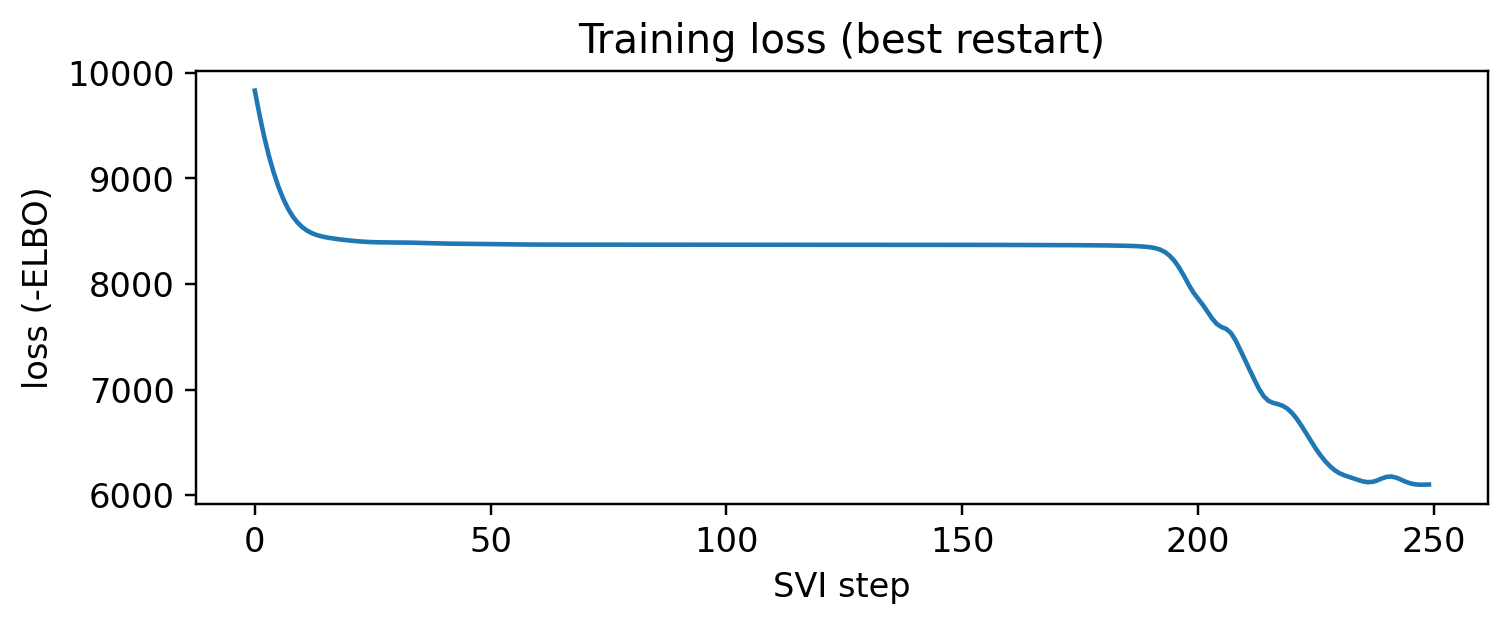

In [5]:
est, losses = learn_best(obs, K, steps=250, restarts=3)
plt.figure(figsize=(7, 3))
plt.plot(losses); plt.xlabel("SVI step"); plt.ylabel("loss (-ELBO)")
plt.title("Training loss (best restart)"); plt.tight_layout(); plt.show()

## Recovered parameters

For continuous emissions, fixing label switching is easy: just **sort the states by their learned mean**. Then we compare to the (already sorted) ground truth.

In [6]:
order = est["locs"].argsort()
mu_e = est["locs"][order].detach()
sd_e = est["scales"][order].detach()
A_e  = est["probs_trans"][order][:, order].detach()
pi_e = est["probs_init"][order].detach()

print("means   true:", mu_true.numpy(), "  learned:", mu_e.numpy().round(2))
print("scales  true:", sd_true.numpy(), "  learned:", sd_e.numpy().round(2))
display(pd.concat({"true A": pd.DataFrame(A_true.numpy(), index=states, columns=states),
                   "learned A": pd.DataFrame(A_e.numpy().round(2), index=states, columns=states)}, axis=1))
print("max abs error  means: %.3f   scales: %.3f   A: %.3f" % (
    (mu_e - mu_true).abs().max(), (sd_e - sd_true).abs().max(), (A_e - A_true).abs().max()))

means   true: [ 0.  5. 10.]   learned: [ 0.04  5.03 10.07]
scales  true: [0.7 0.7 0.7]   learned: [0.71 0.65 0.74]


true A             learned A            
        low   mid  high       low   mid  high
low    0.80  0.15  0.05      0.79  0.16  0.05
mid    0.10  0.80  0.10      0.11  0.80  0.09
high   0.05  0.15  0.80      0.04  0.16  0.80

max abs error  means: 0.074   scales: 0.050   A: 0.013


/tmp/claude-501/ipykernel_63757/3648185236.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  true_pdf = occ[k].item() * np.exp(-0.5*((xs-mu_true[k].item())/sd_true[k].item())**2) / (sd_true[k].item()*np.sqrt(2*np.pi))
/tmp/claude-501/ipykernel_63757/3648185236.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lrn_pdf  = occ[k].item() * np.exp(-0.5*((xs-mu_e[k].item())/sd_e[k].item())**2)       / (sd_e[k].item()*np.sqrt(2*np.pi))


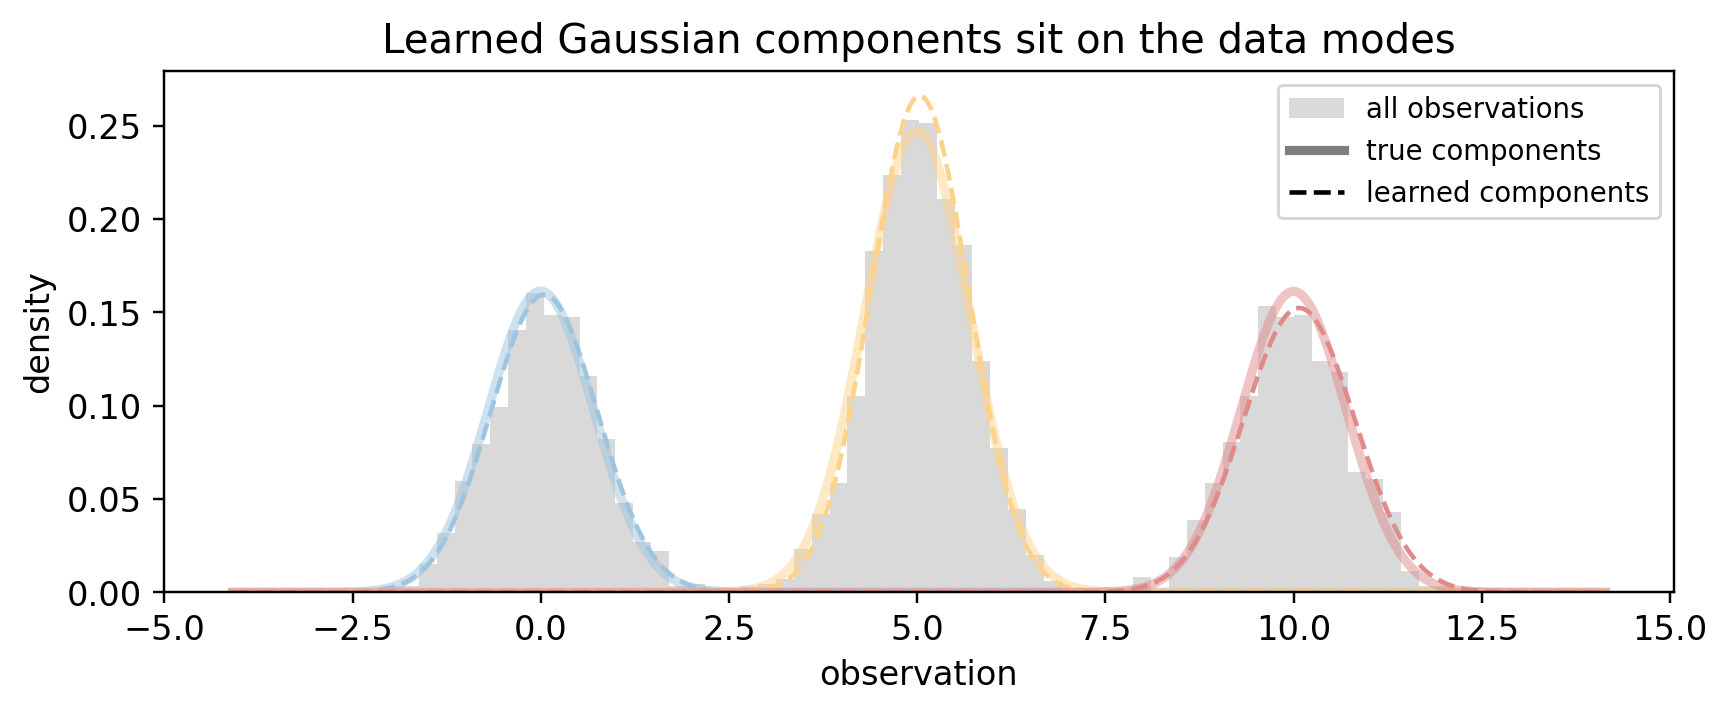

In [7]:
xs = np.linspace(obs.min()-2, obs.max()+2, 400)
occ = torch.bincount(Z.flatten(), minlength=K).float(); occ = occ / occ.sum()
plt.figure(figsize=(8, 3.4))
plt.hist(obs.flatten().numpy(), bins=60, density=True, color="0.85", label="all observations")
for k in range(K):
    true_pdf = occ[k].item() * np.exp(-0.5*((xs-mu_true[k].item())/sd_true[k].item())**2) / (sd_true[k].item()*np.sqrt(2*np.pi))
    lrn_pdf  = occ[k].item() * np.exp(-0.5*((xs-mu_e[k].item())/sd_e[k].item())**2)       / (sd_e[k].item()*np.sqrt(2*np.pi))
    plt.plot(xs, true_pdf, color=colors[k], lw=3, alpha=0.5)
    plt.plot(xs, lrn_pdf,  color=colors[k], lw=1.5, ls="--")
plt.plot([], [], color="k", lw=3, alpha=0.5, label="true components")
plt.plot([], [], color="k", lw=1.5, ls="--", label="learned components")
plt.title("Learned Gaussian components sit on the data modes")
plt.xlabel("observation"); plt.ylabel("density"); plt.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Decoding: segmenting a new signal

Finally, decode a fresh sequence with the learned parameters -- i.e. label each time step with its most likely hidden state (Viterbi via `infer_discrete`) -- and compare to the truth.

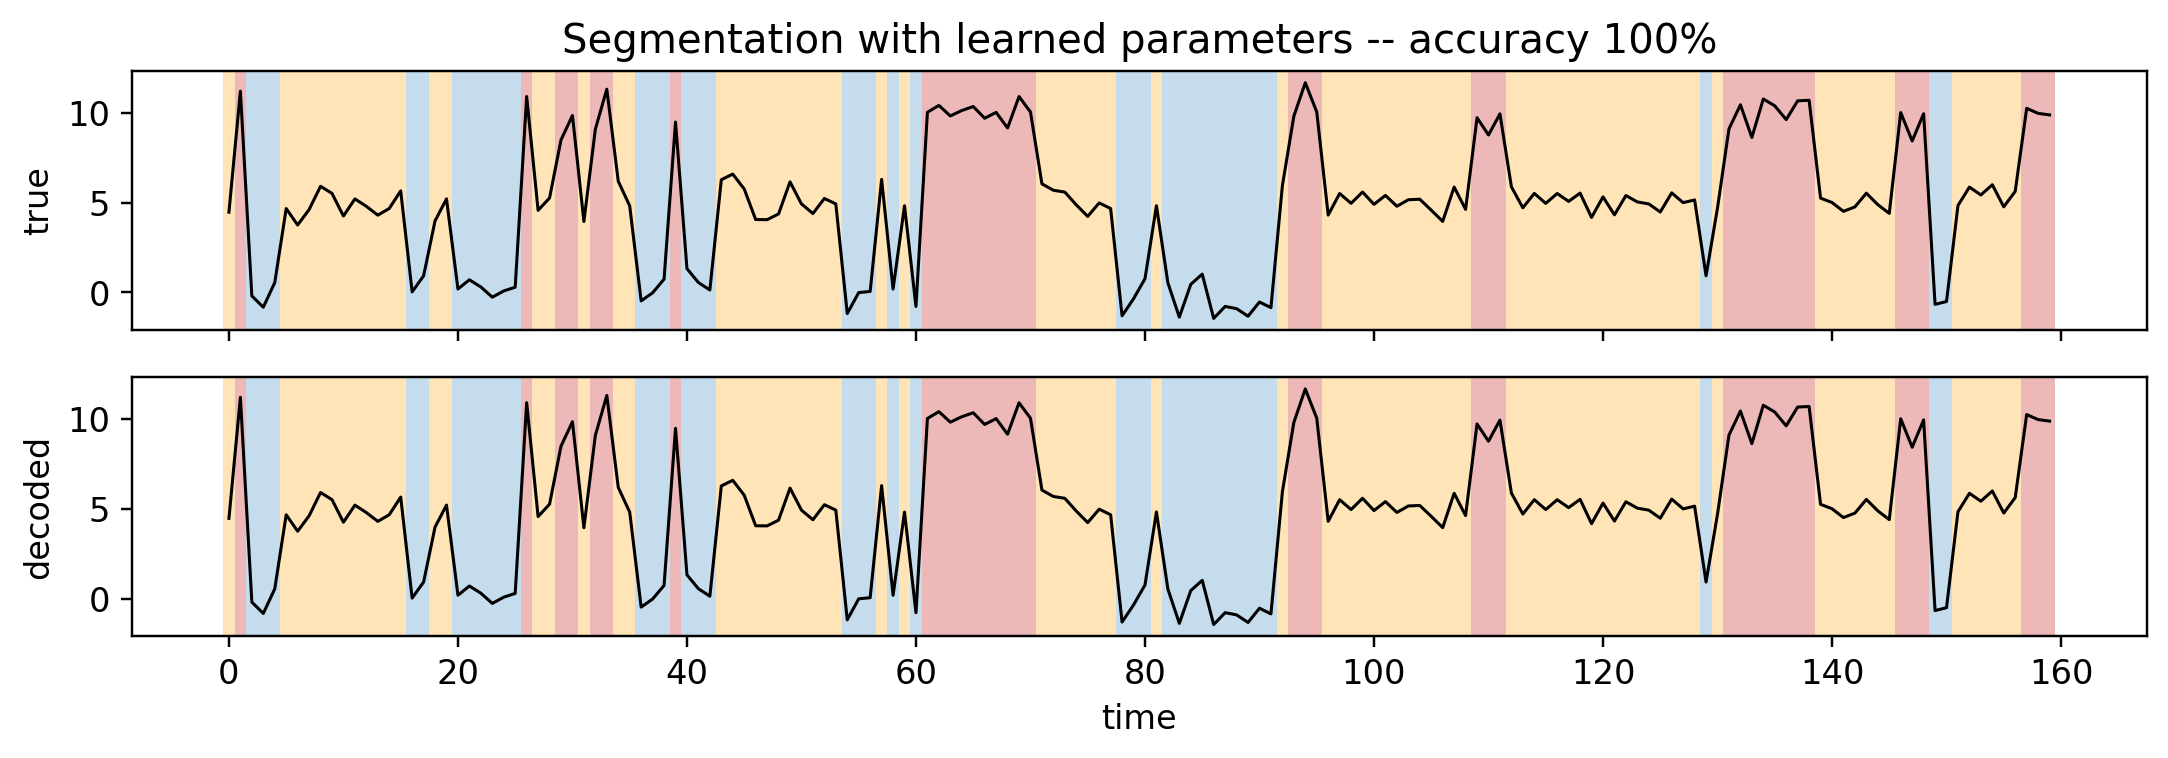

In [8]:
def decode(pi, A, locs, scales, y):
    def m(y):
        z = None
        for t in pyro.markov(range(len(y))):
            probs = pi if t == 0 else Vindex(A)[..., z, :]
            z = pyro.sample(f"z_{t}", dist.Categorical(probs), infer={"enumerate": "parallel"})
            pyro.sample(f"y_{t}", dist.Normal(Vindex(locs)[..., z], Vindex(scales)[..., z]), obs=y[t])
    d = infer_discrete(config_enumerate(m, "parallel"), first_available_dim=-1, temperature=0)
    tr = poutine.trace(d).get_trace(y)
    return [int(tr.nodes[f"z_{t}"]["value"]) for t in range(len(y))]

y_test, z_test = generate(num_seqs=1, T=160, seed=77)
y_test, z_test = y_test[0], z_test[0]
# map learned-state indices back to sorted (true) labels
inv = torch.empty(K, dtype=torch.long); inv[order] = torch.arange(K)
dec = [int(inv[d]) for d in decode(pi_e[inv], A_e[inv][:, inv], mu_e[inv], sd_e[inv], y_test)]
acc = float(np.mean(np.array(dec) == z_test.numpy()))

fig, (b1, b2) = plt.subplots(2, 1, figsize=(10, 3.6), sharex=True)
for t in range(len(y_test)):
    b1.axvspan(t-0.5, t+0.5, color=colors[int(z_test[t])], alpha=0.6, lw=0)
    b2.axvspan(t-0.5, t+0.5, color=colors[dec[t]], alpha=0.6, lw=0)
b1.plot(y_test.numpy(), "k", lw=1); b2.plot(y_test.numpy(), "k", lw=1)
b1.set_ylabel("true"); b2.set_ylabel("decoded"); b2.set_xlabel("time")
b1.set_title(f"Segmentation with learned parameters -- accuracy {acc:.0%}")
plt.tight_layout(); plt.show()

## Wrap-up

A Gaussian-emission HMM was a one-line change from the discrete model, and Pyro recovered the means, spreads, and transitions almost exactly -- then segmented an unseen signal at high accuracy.

This is precisely the model for **a single appliance**: its power trace hops between levels (off / on / boost), each a noisy mean. The catch in real homes is that we do not measure each appliance -- we measure the **sum** at the meter. In the next post we put several of these Gaussian chains together into a **factorial HMM**, written with no Kronecker / product-state machinery, and disaggregate the total back into appliances in time *linear* in the number of appliances.